### Подготовка данных


In [1]:
import os
import shutil
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
home = '/home/slava/Documents/netology_ML/Diplom'

diff_spot_actual_dir = home + '/diff_spot_actual' # скриншоты diff spot

In [3]:
data = []

def create_dataset(path_actual, label):
    for filename in os.listdir(path_actual):
        actual_path = os.path.join(path_actual, filename)
        expected_path = os.path.join(path_actual.replace('actual', 'expected'), filename.replace('actual', 'expected'))
        if os.path.isfile(actual_path) and os.path.isfile(expected_path):
            data.append({
                'actual': str(actual_path),
                'expected': str(expected_path),
                'filename': str(filename),
                'label': label
            })
        else:
            print(f"Пропущен файл {filename}: один из файлов не существует")

create_dataset(diff_spot_actual_dir, 1)
                
df = pd.DataFrame(data)
df.to_csv('labels_6_overeducation.csv', index=False)

                                              actual  \
0  /home/slava/Documents/netology_ML/Diplom/diff_...   
1  /home/slava/Documents/netology_ML/Diplom/diff_...   
2  /home/slava/Documents/netology_ML/Diplom/diff_...   
3  /home/slava/Documents/netology_ML/Diplom/diff_...   
4  /home/slava/Documents/netology_ML/Diplom/diff_...   

                                            expected        filename  label  
0  /home/slava/Documents/netology_ML/Diplom/diff_...  img_002807.jpg      1  
1  /home/slava/Documents/netology_ML/Diplom/diff_...  img_000660.jpg      1  
2  /home/slava/Documents/netology_ML/Diplom/diff_...  img_000653.jpg      1  
3  /home/slava/Documents/netology_ML/Diplom/diff_...  img_000426.jpg      1  
4  /home/slava/Documents/netology_ML/Diplom/diff_...  img_004377.jpg      1  
Всего пар: 3774
С багами: 3774
Без багов: 0


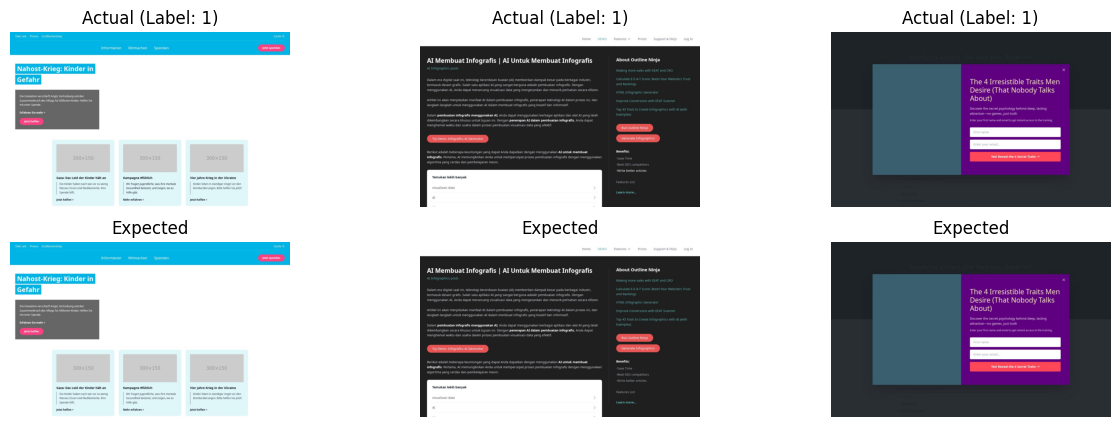

In [4]:
print(df.head())
print(f"Всего пар: {len(df)}")
print(f"С багами: {df['label'].sum()}")
print(f"Без багов: {len(df) - df['label'].sum()}")

def show_samples(df, n=3):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        row = df.sample().iloc[0]
        actual_img = Image.open(row['actual'])
        expected_img = Image.open(row['expected'])
        plt.subplot(2, n, i+1)
        plt.imshow(actual_img)
        plt.title(f'Actual (Label: {row["label"]})')
        plt.axis('off')
        plt.subplot(2, n, n+i+1)
        plt.imshow(expected_img)
        plt.title('Expected')
        plt.axis('off')
    plt.show()

show_samples(df)

In [5]:
df.head(10)

,actual,expected,filename,label
0,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_002807.jpg,1
1,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_000660.jpg,1
2,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_000653.jpg,1
3,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_000426.jpg,1
4,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_004377.jpg,1
5,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_001972.jpg,1
6,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_003769.jpg,1
7,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_000334.jpg,1
8,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_003595.jpg,1
9,/home/slava/Documents/netology_ML/Diplom/diff_...,/home/slava/Documents/netology_ML/Diplom/diff_...,img_002140.jpg,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   actual    3774 non-null   object
 1   expected  3774 non-null   object
 2   filename  3774 non-null   object
 3   label     3774 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 118.1+ KB


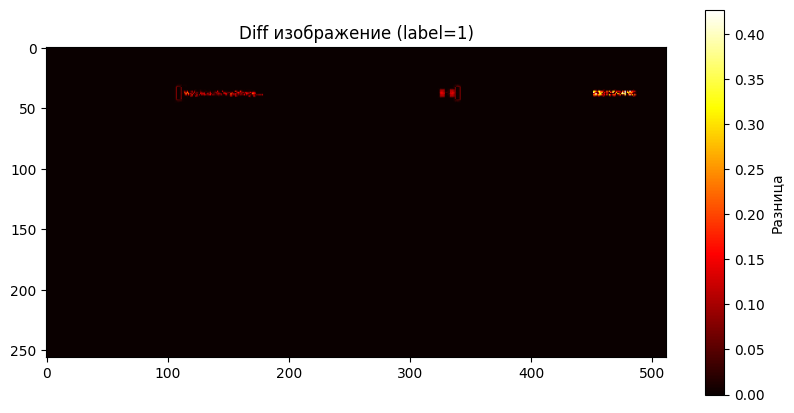

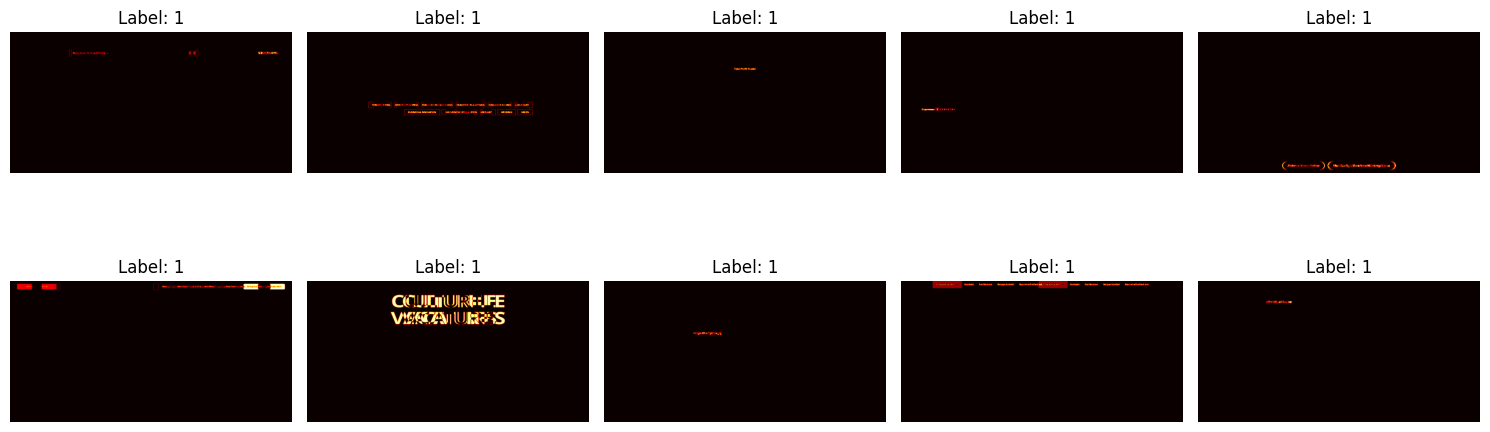

In [7]:
IMG_SIZE = (512, 256)  # до какого размера сжимаем изображения

def compress_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация

X = []
y = []
actual_images = []
expected_images = []

for _, row in df.iterrows():
    actual = compress_image(row['actual'])
    expected = compress_image(row['expected'])
    actual_images.append(actual)
    expected_images.append(expected)

    # Вычисляем абсолютную разницу (в градациях серого)
    diff = np.abs(actual - expected)  # форма: (h, w)
    
    X.append(diff)
    y.append(row['label'])

joblib.dump(actual_images, 'actual_images_after_compress_6_overeducation.joblib')
joblib.dump(expected_images, 'expected_images_after_compress_6_overeducation.joblib')
joblib.dump(X, 'diff_images_after_compress_6_overeducation.joblib')
joblib.dump(y, 'y_labels_6_overeducation.joblib')

X = np.array(X)  # вертор разницы
y = np.array(y)  # метки: 0 или 1

# Визуализация первого diff-изображения
plt.figure(figsize=(10, 5))
plt.imshow(X[0], cmap='hot')
plt.colorbar(label='Разница')
plt.title(f'Diff изображение (label={y[0]})')
plt.show()

# Сравнение нескольких образцов
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X):
        ax.imshow(X[i], cmap='hot')
        ax.set_title(f'Label: {y[i]}')
        ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
print(f"Форма X: {X.shape}")
print(f"Тип данных X: {X.dtype}")
print(f"Количество образцов: {len(X)}")
print(f"Диапазон значений: min={X.min():.4f}, max={X.max():.4f}")
print(f"Среднее значение: {X.mean():.4f}")
print(f"Стандартное отклонение: {X.std():.4f}")

Форма X: (3774, 256, 512)
Тип данных X: float64
Количество образцов: 3774
Диапазон значений: min=0.0000, max=1.0000
Среднее значение: 0.0042
Стандартное отклонение: 0.0392


### Анализ
Мы сжали изображения и вывели их разницу. 
Явно видно, что у нас большая часть данных - это нулевые значения (черный фон).
Вырежем изменения, так как позиция места разницы не несет значимых признаков.

Размеры до обрезки: (256, 512)
Размеры после обрезки: (33, 399)
Пример координат: (np.int64(31), np.int64(107))
Средний размер после обрезки: 115.46595124536302


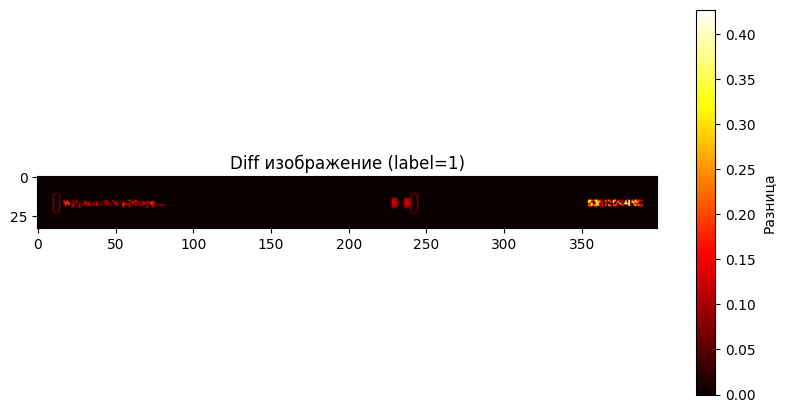

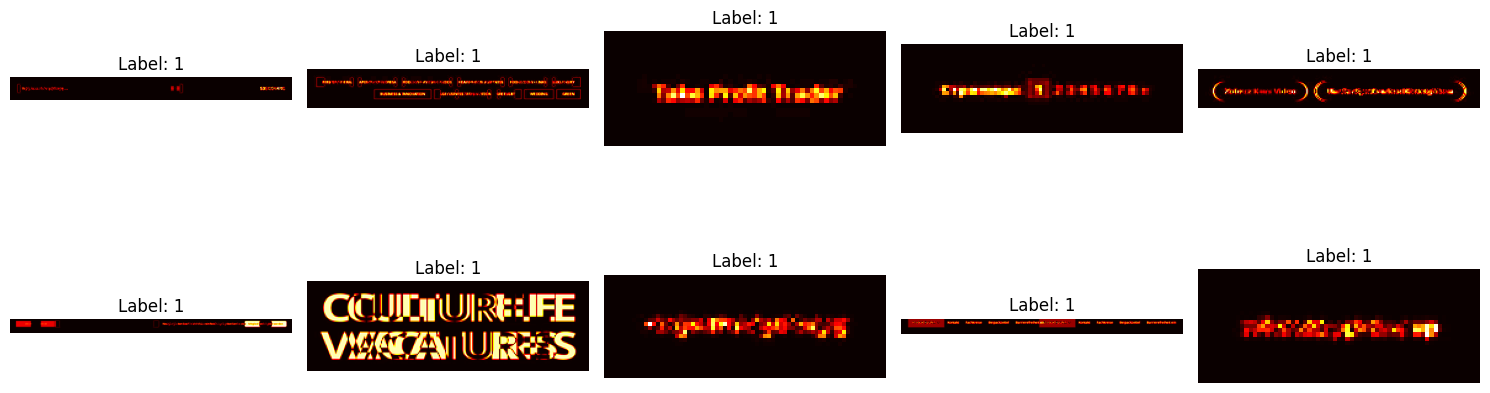

In [9]:
def crop_to_content_with_coords(image, threshold=0.01):
    """
    Обрезает изображение до области с информацией и возвращает координаты.
    
    Returns:
        cropped: обрезанное изображение
        top_left: кортеж (y, x) — координаты верхнего левого угла обрезанной области 
                  относительно исходного изображения (до применения padding)
    """
    mask = image > threshold
    
    if not mask.any():
        return np.zeros((10, 10)), (0, 0)
    
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    
    # Сохраняем координаты ДО добавления padding
    top_left_y = rmin
    top_left_x = cmin
    
    padding = 10
    rmin = max(0, rmin - padding)
    rmax = min(image.shape[0], rmax + padding)
    cmin = max(0, cmin - padding)
    cmax = min(image.shape[1], cmax + padding)
    
    cropped = image[rmin:rmax, cmin:cmax]
    top_left = (top_left_y, top_left_x)
    
    return cropped, top_left

X_cropped = []
X_coords = []
for img in X:
    cropped, coords = crop_to_content_with_coords(img)
    X_cropped.append(cropped)
    X_coords.append(coords)

# Проверяем результаты
print(f"Размеры до обрезки: {X[0].shape}")
print(f"Размеры после обрезки: {X_cropped[0].shape}")
print(f"Пример координат: {X_coords[0]}")
print(f"Средний размер после обрезки: {np.mean([img.shape for img in X_cropped])}")

# Визуализация первого diff-изображения
plt.figure(figsize=(10, 5))
plt.imshow(X_cropped[0], cmap='hot')
plt.colorbar(label='Разница')
plt.title(f'Diff изображение (label={y[0]})')
plt.show()

# Сравнение нескольких образцов
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_cropped):
        ax.imshow(X_cropped[i], cmap='hot')
        ax.set_title(f'Label: {y[i]}')
        ax.axis('off')
plt.tight_layout()
plt.show()

## Анализ
Мы максимально уменьшили объем данных отбросив лишнее. Даже на глаз понятно, что для пропадающих элементов дефект выглядит явно и не составит труда его классифицировать, то как же обстоят дела со сдвигом и динамическими элементами?

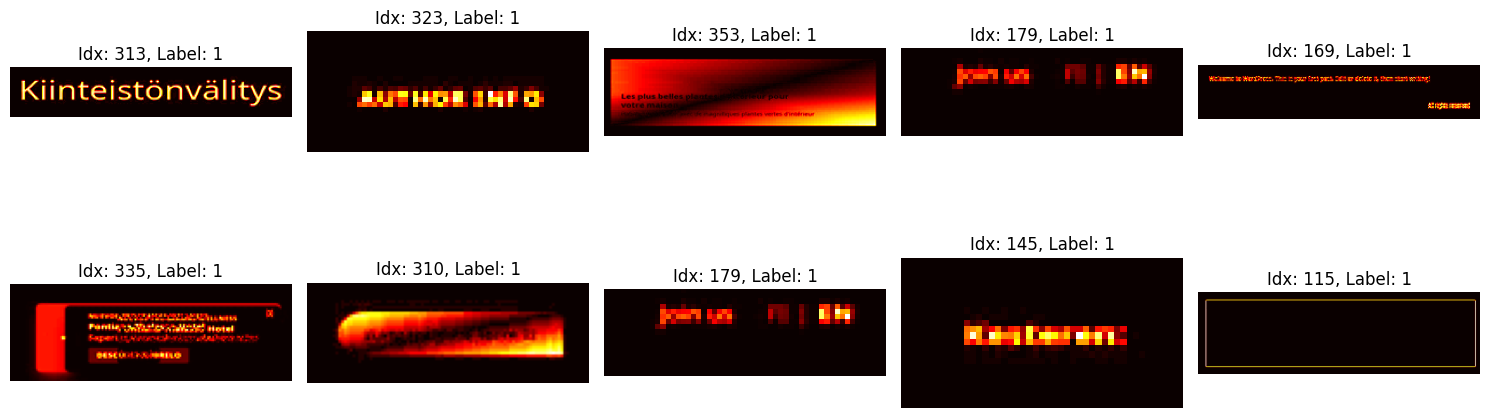

In [10]:
# индексы для анализа
indices = [313, 323, 353, 179, 169, 335, 310, 179, 145, 115]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(indices):
        idx = indices[i]
        if idx < len(X_cropped):
            ax.imshow(X_cropped[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

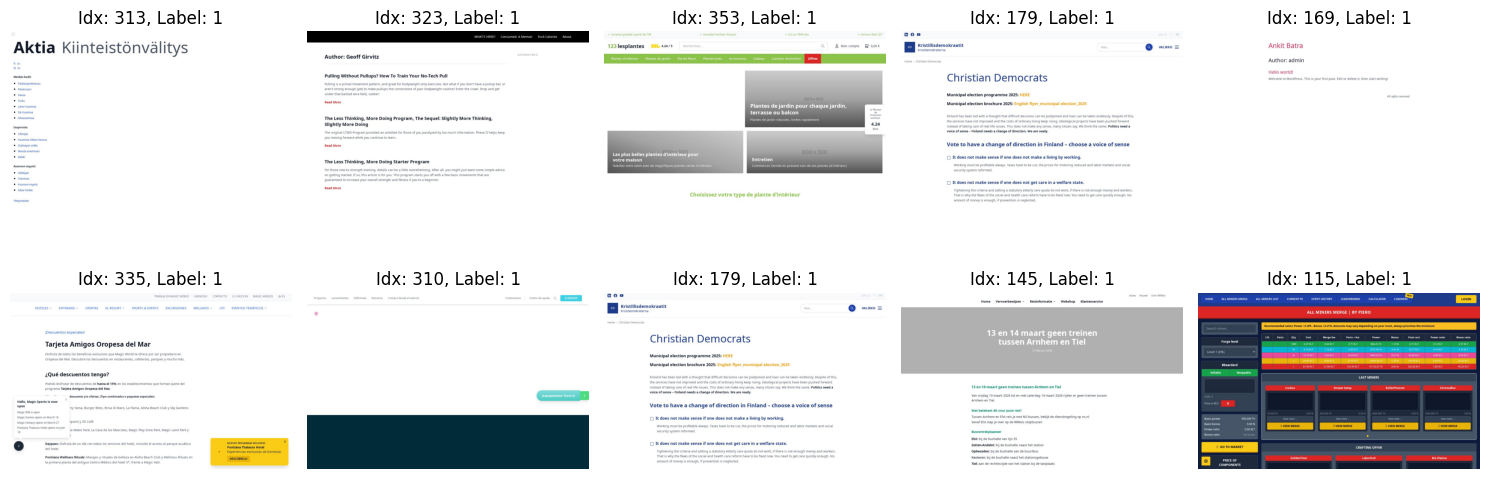

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flat

for i, ax in enumerate(axes):
    if i < len(indices):
        idx = indices[i]
        row = df.loc[idx]  # Получаем строку по индексу
        actual_img = Image.open(row['actual'])
        expected_img = Image.open(row['expected'])
        
        ax.imshow(np.array(actual_img))
        ax.set_title(f'Idx: {idx}, Label: {row["label"]}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
joblib.dump(X_cropped, 'X_cropped_diff_images_6_overeducation.joblib')
joblib.dump(X_coords, 'X_coords_diff_images_6_overeducation.joblib')
joblib.dump(y, 'y_labels_6_overeducation.joblib')

['y_labels_6_overeducation.joblib']